## APhys Group Meeting, 01.04.2026

Overturning scales and turbulence from CTD.

In [1]:
# imports
import ewgreaders as ewg
import os
from glob import glob
import xarray as xr
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
def rolling_average(data, depth, ra_window):
    """
    Compute rolling average.

    Parameters
    ----------
    data : array_like
        Data variable to compute rolling average of.
    depth : array_like
        Depth below water surface.
    ra_window : float
        Depth window for rolling average.

    Returns
    -------
    data_ra : xr.DataArray
        Rolling average of data.
    """
    data_ra = []
    for d in depth:
        mask = (depth >= d - (ra_window/2)) & (depth <= d + (ra_window/2))
        data_ra.append(np.mean(data[mask]))


    return xr.DataArray(data_ra, dims=data.dims, coords=data.coords, name=data.name)


def order_profile(var, depth, descending):
    """
    Order profile.  Stable so repeat values maintain original order.

    Parameters
    ----------
    var : xr.DataArray
        Variable profile to sort.
    depth : xr.DataArray
        Depth below water surface, increasing.
    descending : bool
        True if var decreases with depth, False if var increases with depth.
    """
    if descending:
        s = -1
    else:
        s = 1

    var_ascending = var*s
    idx = var_ascending.argsort(kind='mergesort').values
    var_sorted = var_ascending.isel(depth=idx)

    return var_sorted*s


def brunt_vaisala_frequency(ds, sort=True):
    """
    Calculate Brunt-Väisälä (buoyancy) frequency.
    N^2 = (g / ρ) * (dρ/dz)
    z represents depth, with z = 0 at the surface.

    Parameters
    ----------
    ds : xr.Dataset
        CTD data.
    sort : bool
        If True, sort profile to monotonic order.

    Returns
    -------
    N2 : xr.DataArray
    """
    g = 9.81

    depth = ds['depth']
    rho = ds['rho']

    # sort density profile, use original depth
    if sort:
        rho = order_profile(rho, depth, False)
        rho = rho.assign_coords(depth=depth)

    drhodz = rho.differentiate('depth')
    N2 = (g/rho.values) * drhodz          # use midpoint depths from derivative

    return N2.rename('N2')

### 2026.01.13

In [60]:
lake = 'Zug'
year = '2026'
date = '20260113'

dpath_ctd = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/CTD/{date}/L2'
dpath_mctd = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Microstructure/{date}/L2'

fpaths_ctd = glob(f'{dpath_ctd}/*.nc')
fpaths_mctd = glob(f'{dpath_mctd}/*.nc')

In [61]:
eps_c, eps_w, eps_s = [], [], []

for fpath in fpaths_mctd:
    ds = xr.open_dataset(fpath)
    mask = (ds['BINNED_flag_T1'] == 0) & (ds['BINNED_flag_T2'] == 0) & (ds['BINNED_depth'] > 5)

    eps = xr.concat([ds['BINNED_eps_T1'][mask], ds['BINNED_eps_T2'][mask]], dim='sensor').mean(dim='sensor')
    chi = xr.concat([ds['BINNED_Xi_T1'][mask], ds['BINNED_Xi_T2'][mask]], dim='sensor').mean(dim='sensor')
    K = xr.concat([ds['BINNED_KOsbornCox_T1'][mask], ds['BINNED_KOsbornCox_T2'][mask]], dim='sensor').mean(dim='sensor')

    # VMPS
    if 'DAT_053' in fpath:
        eps_s.append(eps)

    # VMPC
    elif 'DAT_055' in fpath or 'DAT_059' in fpath:
        eps_c.append(eps)

    # VMPW
    elif 'DAT_057' in fpath:
        eps_w.append(eps)

eps_s = xr.concat(eps_s, dim='BINNED_depth').sortby('BINNED_depth')
eps_c = xr.concat(eps_c, dim='BINNED_depth').sortby('BINNED_depth')
eps_w = xr.concat(eps_w, dim='BINNED_depth').sortby('BINNED_depth')

# 5 meter bins
bins_s = np.arange(0, eps_s['BINNED_depth'].max() + 5, 5)
eps_s_avg = eps_s.groupby_bins("BINNED_depth", bins_s).median()
bc_s = np.array([b.mid for b in eps_s_avg['BINNED_depth_bins'].values])

bins_c = np.arange(0, eps_c['BINNED_depth'].max() + 5, 5)
eps_c_avg = eps_c.groupby_bins("BINNED_depth", bins_c).median()
bc_c = np.array([b.mid for b in eps_c_avg['BINNED_depth_bins'].values])

bins_w = np.arange(0, eps_w['BINNED_depth'].max() + 5, 5)
eps_w_avg = eps_w.groupby_bins("BINNED_depth", bins_w).median()
bc_w = np.array([b.mid for b in eps_w_avg['BINNED_depth_bins'].values])

In [66]:
g = 9.81
alpha = 0.8

data = []
ctd_data = []
for fpath in fpaths_ctd:
    ds = xr.open_dataset(fpath)

    # data quality
    mask = (ds.fall_speed > 0.1) & (ds.fall_speed < 0.33)
    ds = ds.where(mask, drop=True)

    rho = ds['rho']
    temp = ds['temp']
    depth = ds['depth']
    do = ds['do2_conc']

    rho_ra = rolling_average(rho, depth, ra_window=1)

    # thorpe displacement
    rho_sorted = order_profile(rho_ra, depth, False)
    thorpe_displacement = (depth - rho_sorted.depth.values).rename('thorpe_displacement')

    # temperature
    temp_sorted = order_profile(temp, depth, True)
    temp_displacement = (depth - temp_sorted.depth.values).rename('temp_displacement')

    # dissolved oxygen
    mask_anoxic = do > do.min() + 0.02
    do_sorted = order_profile(do[mask_anoxic], depth[mask_anoxic], True)
    do_displacement = (depth[mask_anoxic] - do_sorted.depth.values).rename('do_displacement')

    # buoyancy frequency (sorted rho, 1 meter bins)
    rho_sorted = rho_sorted.assign_coords(depth=depth)
    bins = np.arange(0, rho_sorted['depth'].max() + 1, 1)
    rho_bin = rho_sorted.groupby_bins('depth', bins).mean()
    bc = rho_bin.indexes['depth_bins'].mid
    rho_bin = rho_bin.assign_coords(depth_bins=bc)
    rho_bin = rho_bin.rename({'depth_bins': 'depth'})
    drhodz = rho_bin.differentiate('depth')
    N2 = (g/rho_bin.values) * drhodz

    # bin thorpe, temperature, dissolved oxygen displacements onto same grid as N2
    thorpe_bin = abs(thorpe_displacement).groupby_bins('depth', bins).mean()
    thorpe_bin = thorpe_bin.assign_coords(depth_bins=bc)
    thorpe_bin = thorpe_bin.rename({'depth_bins': 'depth'})

    temp_bin = abs(temp_displacement).groupby_bins('depth', bins).mean()
    temp_bin = temp_bin.assign_coords(depth_bins=bc)
    temp_bin = temp_bin.rename({'depth_bins': 'depth'})

    do_bin = abs(do_displacement).groupby_bins('depth', bins).mean()
    do_bin = do_bin.assign_coords(depth_bins=bc)
    do_bin = do_bin.rename({'depth_bins': 'depth'})

    # estimate epsilon
    N3 = N2 ** (3/2)
    eps = (alpha**2) * N3 * thorpe_bin
    eps_temp = (alpha**2) * N3 * temp_bin
    eps_do = (alpha**2) * N3 * do_bin

    dat = pd.DataFrame({
        'depth': bc,
        'eps': eps,
        'eps_temp': eps_temp,
        'eps_do': eps_do
    })
    dat[['date', 'time', 'profile_loc']] = ds.attrs['date'], ds.attrs['time'], ds.attrs['profile_loc']
    data.append(dat)

    ctd_dat = pd.DataFrame({
        'depth': depth,
        'rho': rho_ra,
        'temp':temp,
        'do': do
    })
    ctd_dat[['date', 'time', 'profile_loc']] = ds.attrs['date'], ds.attrs['time'], ds.attrs['profile_loc']
    ctd_data.append(ctd_dat)

data = pd.concat(data, ignore_index=True)
ctd_data = pd.concat(ctd_data, ignore_index=True)

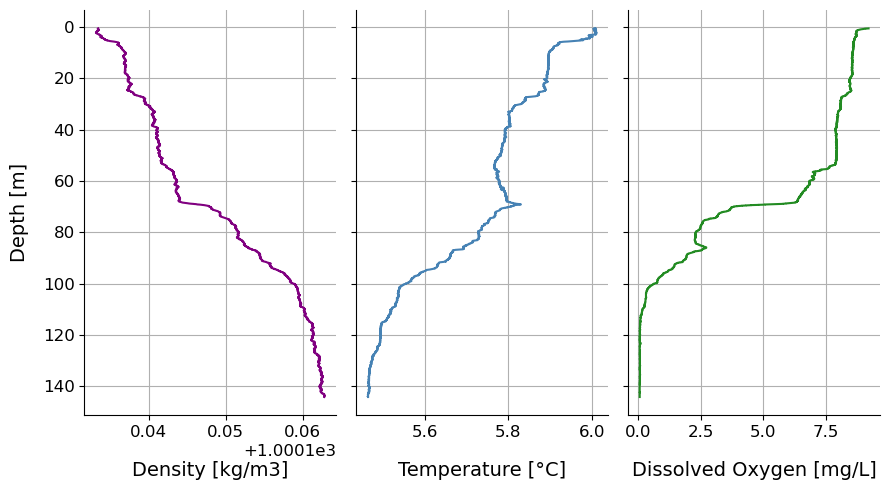

In [90]:
# single profile example
df_sel = ctd_data.query("time == '16:23'")

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(9, 5), sharey=True)

sns.lineplot(df_sel, x='rho', y='depth', orient='y', color='purple', ax=ax[0])
sns.lineplot(df_sel, x='temp', y='depth', orient='y', color='steelblue', ax=ax[1])
sns.lineplot(df_sel, x='do', y='depth', orient='y', color='forestgreen', ax=ax[2])

ax[0].set_xlabel('Density [kg/m3]', fontsize=14, labelpad=15)
ax[1].set_xlabel('Temperature [°C]', fontsize=14, labelpad=15)
ax[2].set_xlabel('Dissolved Oxygen [mg/L]', fontsize=14, labelpad=15)
ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[0].xaxis.get_offset_text().set_fontsize(12)

ax[0].invert_yaxis()
for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)


plt.tight_layout()
plt.savefig('../../gallery/aphys/2026_04_01/ctd.png', bbox_inches='tight')
plt.show()

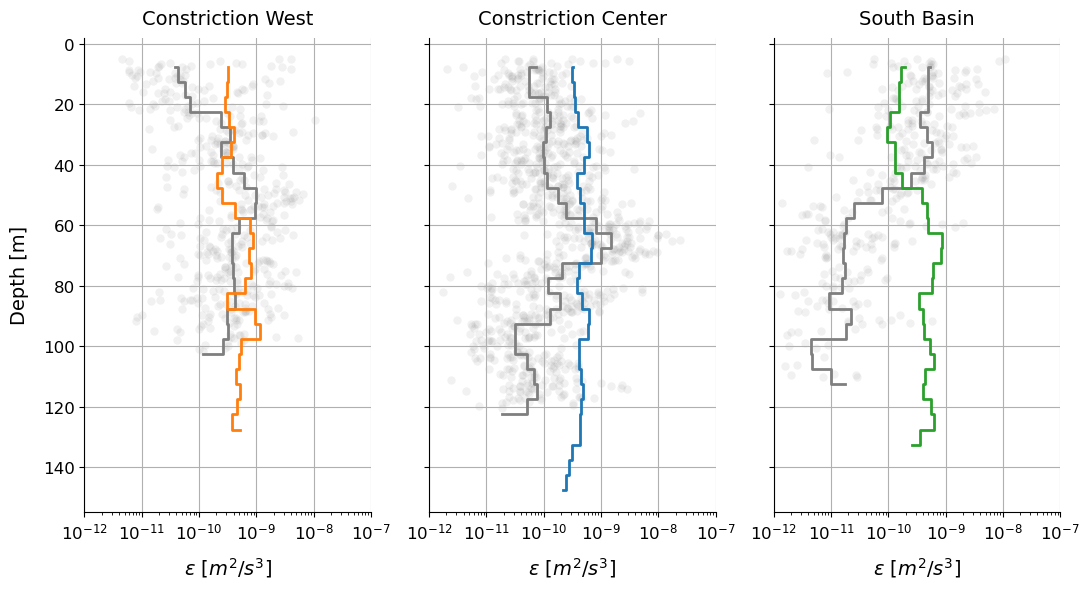

In [91]:
# average CTD profiles at same location
data = data.replace(0, np.nan)
data_avg = (data.query("depth > 5")
    .assign(depth_bin = lambda x: (x['depth'] // 5) * 5 + 2.5)
    .groupby(['profile_loc', 'depth_bin'])[['eps', 'eps_temp', 'eps_do']]
    .median()
    .reset_index()
).rename(columns={'depth_bin': 'depth'})
#data_avg = data.query("depth > 5").groupby(['profile_loc', 'depth'])[['eps', 'eps_temp', 'eps_do']].mean().reset_index()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 6), sharey=True, sharex=True)
var_order = ['eps', 'eps_temp', 'eps_do']
palette = 'YlGnBu_d'

# VMPW
sns.scatterplot(x=eps_w, y=eps_w['BINNED_depth'], color='tab:gray', alpha=0.1, ax=ax[0])
sns.lineplot(x=eps_w_avg, y=bc_w, orient='y', color='tab:gray', linewidth=2, drawstyle="steps-mid", ax=ax[0])
sns.lineplot(data_avg.query("profile_loc == 'VMPW'"), x='eps', y='depth', orient='y', color='tab:orange', linewidth=2, drawstyle='steps-mid', ax=ax[0], legend=False)

# VMPC
sns.scatterplot(x=eps_c, y=eps_c['BINNED_depth'], color='tab:gray', alpha=0.1, ax=ax[1])
sns.lineplot(x=eps_c_avg, y=bc_c, orient='y', color='tab:gray', linewidth=2, drawstyle="steps-mid", ax=ax[1])
sns.lineplot(data_avg.query("profile_loc == 'VMPC'"), x='eps', y='depth', orient='y', color='tab:blue', linewidth=2, drawstyle='steps-mid', ax=ax[1], legend=False)

# VMPS
sns.scatterplot(x=eps_s, y=eps_s['BINNED_depth'], color='tab:gray', alpha=0.1, ax=ax[2])
sns.lineplot(x=eps_s_avg, y=bc_s, orient='y', color='tab:gray', linewidth=2, drawstyle="steps-mid", ax=ax[2])
sns.lineplot(data_avg.query("profile_loc == 'VMPS'"), x='eps', y='depth', orient='y', color='tab:green', linewidth=2, drawstyle='steps-mid', ax=ax[2])

ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[0].set_title('Constriction West', fontsize=14, pad=10)
ax[1].set_title('Constriction Center', fontsize=14, pad=10)
ax[2].set_title('South Basin', fontsize=14, pad=10)

ax[0].invert_yaxis()
ax[0].set_xlim(1e-12, 1e-7)
ax[0].set_xscale('log')

for i in range(len(ax)):
    ax[i].set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

plt.tight_layout()
plt.savefig('../../gallery/aphys/2026_04_01/eps.png', bbox_inches='tight')
plt.show()

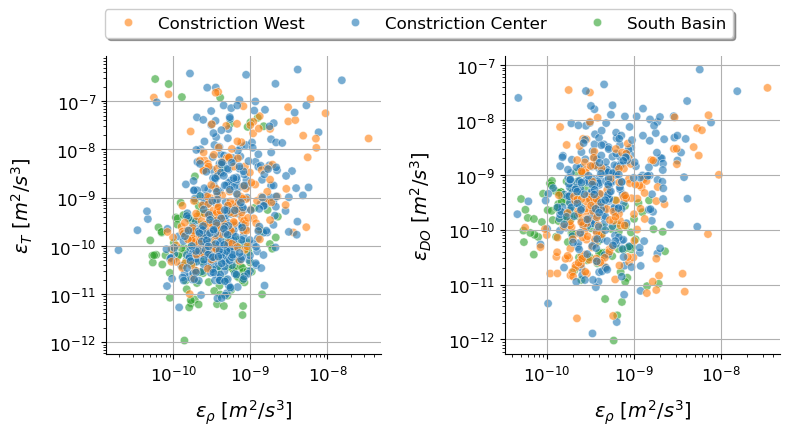

In [92]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
loc_order = ['VMPW', 'VMPC', 'VMPS']
palette = ['tab:orange', 'tab:blue', 'tab:green']

sns.scatterplot(data.query("depth > 5"), x='eps', y='eps_temp', hue='profile_loc', hue_order=loc_order, palette=palette, alpha=0.6, ax=ax[0], legend=False)
sns.scatterplot(data.query("depth > 5"), x='eps', y='eps_do', hue='profile_loc', hue_order=loc_order, palette=palette, alpha=0.6, ax=ax[1])

ax[0].set_ylabel(r'$\epsilon_{T}$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
ax[1].set_ylabel(r'$\epsilon_{DO}$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)

for i in range(len(ax)):
    ax[i].set_xlabel(r'$\epsilon_{\rho}$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].grid(True)

labels = ['Constriction West', 'Constriction Center', 'South Basin']
handles, _ = ax[1].get_legend_handles_labels()
ax[1].get_legend().remove()
fig.legend(handles, labels, fontsize=12, ncols=3, shadow=True, loc='upper center', bbox_to_anchor=(0.53, 1.1))

plt.tight_layout(w_pad=2)
plt.savefig('../../gallery/aphys/2026_04_01/overturn_scales.png', bbox_inches='tight')
plt.show()

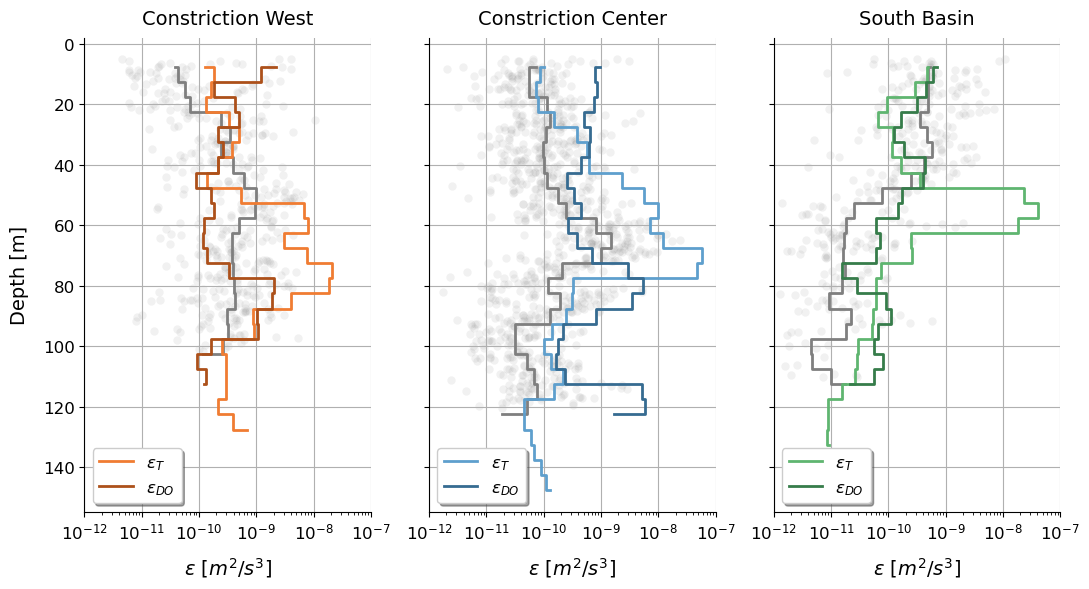

In [93]:
dfm = pd.melt(data_avg, id_vars=['profile_loc', 'depth'], value_vars=['eps_temp', 'eps_do'], var_name='calculation', value_name='epsilon')

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 6), sharey=True, sharex=True)
var_order = ['eps_temp', 'eps_do']
palette = 'YlGnBu_d'

# VMPW
sns.scatterplot(x=eps_w, y=eps_w['BINNED_depth'], color='tab:gray', alpha=0.1, ax=ax[0])
sns.lineplot(x=eps_w_avg, y=bc_w, orient='y', color='tab:gray', linewidth=2, drawstyle="steps-mid", ax=ax[0])
sns.lineplot(dfm.query("profile_loc == 'VMPW'"), x='epsilon', y='depth', orient='y', hue='calculation', hue_order=var_order, palette='Oranges_d', 
             linewidth=2, drawstyle='steps-mid', ax=ax[0])


# VMPC
sns.scatterplot(x=eps_c, y=eps_c['BINNED_depth'], color='tab:gray', alpha=0.1, ax=ax[1])
sns.lineplot(x=eps_c_avg, y=bc_c, orient='y', color='tab:gray', linewidth=2, drawstyle="steps-mid", ax=ax[1])
sns.lineplot(dfm.query("profile_loc == 'VMPC'"), x='epsilon', y='depth', orient='y', hue='calculation', hue_order=var_order, palette='Blues_d', 
             linewidth=2, drawstyle='steps-mid', ax=ax[1])

# VMPS
sns.scatterplot(x=eps_s, y=eps_s['BINNED_depth'], color='tab:gray', alpha=0.1, ax=ax[2])
sns.lineplot(x=eps_s_avg, y=bc_s, orient='y', color='tab:gray', linewidth=2, drawstyle="steps-mid", ax=ax[2])
sns.lineplot(dfm.query("profile_loc == 'VMPS'"), x='epsilon', y='depth', orient='y', hue='calculation', hue_order=var_order, palette='Greens_d', 
             linewidth=2, drawstyle='steps-mid', ax=ax[2])

ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[0].set_title('Constriction West', fontsize=14, pad=10)
ax[1].set_title('Constriction Center', fontsize=14, pad=10)
ax[2].set_title('South Basin', fontsize=14, pad=10)

ax[0].invert_yaxis()
ax[0].set_xlim(1e-12, 1e-7)
ax[0].set_xscale('log')

labels = [r'$\epsilon_{T}$', r'$\epsilon_{DO}$']
for i in range(len(ax)):
    ax[i].set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)
    handles, _ = ax[i].get_legend_handles_labels()
    ax[i].legend(handles, labels, fontsize=12, shadow=True)

plt.tight_layout()
plt.savefig('../../gallery/aphys/2026_04_01/eps_temp_do.png', bbox_inches='tight')
plt.show()

### 2026.02.13

In [46]:
lake = 'Zug'
year = '2026'
date = '20260213'

dpath_ctd = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/CTD/{date}/L2'
dpath_mctd = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Microstructure/{date}/Level2'

fpaths_ctd = glob(f'{dpath_ctd}/*.nc')
fpaths_mctd = glob(f'{dpath_mctd}/*.nc')

In [47]:
eps_c, eps_w, eps_s = [], [], []

for fpath in fpaths_mctd:
    ds = xr.open_dataset(fpath)
    mask = (ds['BINNED_flag_T1'] == 0) & (ds['BINNED_flag_T2'] == 0) & (ds['BINNED_depth'] > 5)

    eps = xr.concat([ds['BINNED_eps_T1'][mask], ds['BINNED_eps_T2'][mask]], dim='sensor').mean(dim='sensor')
    chi = xr.concat([ds['BINNED_Xi_T1'][mask], ds['BINNED_Xi_T2'][mask]], dim='sensor').mean(dim='sensor')
    K = xr.concat([ds['BINNED_KOsbornCox_T1'][mask], ds['BINNED_KOsbornCox_T2'][mask]], dim='sensor').mean(dim='sensor')

    # VMPS
    if 'DAT_095' in fpath:
        eps_s.append(eps)

    # VMPC
    elif 'DAT_093' in fpath:
        eps_c.append(eps)

    # VMPW
    elif 'DAT_094' in fpath:
        eps_w.append(eps)

eps_s = xr.concat(eps_s, dim='BINNED_depth').sortby('BINNED_depth')
eps_c = xr.concat(eps_c, dim='BINNED_depth').sortby('BINNED_depth')
eps_w = xr.concat(eps_w, dim='BINNED_depth').sortby('BINNED_depth')

# 5 meter bins
bins_s = np.arange(0, eps_s['BINNED_depth'].max() + 5, 5)
eps_s_avg = eps_s.groupby_bins("BINNED_depth", bins_s).median()
bc_s = np.array([b.mid for b in eps_s_avg['BINNED_depth_bins'].values])

bins_c = np.arange(0, eps_c['BINNED_depth'].max() + 5, 5)
eps_c_avg = eps_c.groupby_bins("BINNED_depth", bins_c).median()
bc_c = np.array([b.mid for b in eps_c_avg['BINNED_depth_bins'].values])

bins_w = np.arange(0, eps_w['BINNED_depth'].max() + 5, 5)
eps_w_avg = eps_w.groupby_bins("BINNED_depth", bins_w).median()
bc_w = np.array([b.mid for b in eps_w_avg['BINNED_depth_bins'].values])

In [48]:
g = 9.81
alpha = 0.8

data = []
for fpath in fpaths_ctd:
    ds = xr.open_dataset(fpath)

    if ds.attrs['profile_loc'] not in ['VMPW', 'VMPC', 'VMPS']:
        continue

    # data quality
    mask = (ds.fall_speed > 0.1) & (ds.fall_speed < 0.33)
    ds = ds.where(mask, drop=True)

    rho = ds['rho']
    temp = ds['temp']
    depth = ds['depth']
    do = ds['do2_conc']

    rho_ra = rolling_average(rho, depth, ra_window=1)

    # thorpe displacement
    rho_sorted = order_profile(rho_ra, depth, False)
    thorpe_displacement = (depth - rho_sorted.depth.values).rename('thorpe_displacement')

    # temperature
    temp_sorted = order_profile(temp, depth, True)
    temp_displacement = (depth - temp_sorted.depth.values).rename('temp_displacement')

    # dissolved oxygen
    mask_anoxic = do > do.min() + 0.02
    do_sorted = order_profile(do[mask_anoxic], depth[mask_anoxic], True)
    do_displacement = (depth[mask_anoxic] - do_sorted.depth.values).rename('do_displacement')

    # buoyancy frequency (sorted rho, 1 meter bins)
    rho_sorted = rho_sorted.assign_coords(depth=depth)
    bins = np.arange(0, rho_sorted['depth'].max() + 1, 1)
    rho_bin = rho_sorted.groupby_bins('depth', bins).mean()
    bc = rho_bin.indexes['depth_bins'].mid
    rho_bin = rho_bin.assign_coords(depth_bins=bc)
    rho_bin = rho_bin.rename({'depth_bins': 'depth'})
    drhodz = rho_bin.differentiate('depth')
    N2 = (g/rho_bin.values) * drhodz

    # bin thorpe, temperature, dissolved oxygen displacements onto same grid as N2
    thorpe_bin = abs(thorpe_displacement).groupby_bins('depth', bins).mean()
    thorpe_bin = thorpe_bin.assign_coords(depth_bins=bc)
    thorpe_bin = thorpe_bin.rename({'depth_bins': 'depth'})

    temp_bin = abs(temp_displacement).groupby_bins('depth', bins).mean()
    temp_bin = temp_bin.assign_coords(depth_bins=bc)
    temp_bin = temp_bin.rename({'depth_bins': 'depth'})

    do_bin = abs(do_displacement).groupby_bins('depth', bins).mean()
    do_bin = do_bin.assign_coords(depth_bins=bc)
    do_bin = do_bin.rename({'depth_bins': 'depth'})

    # estimate epsilon
    N3 = N2 ** (3/2)
    eps = (alpha**2) * N3 * thorpe_bin
    eps_temp = (alpha**2) * N3 * temp_bin
    eps_do = (alpha**2) * N3 * do_bin

    dat = pd.DataFrame({
        'depth': bc,
        'eps': eps,
        'eps_temp': eps_temp,
        'eps_do': eps_do
    })
    dat[['date', 'time', 'profile_loc']] = ds.attrs['date'], ds.attrs['time'], ds.attrs['profile_loc']
    data.append(dat)

data = pd.concat(data, ignore_index=True)

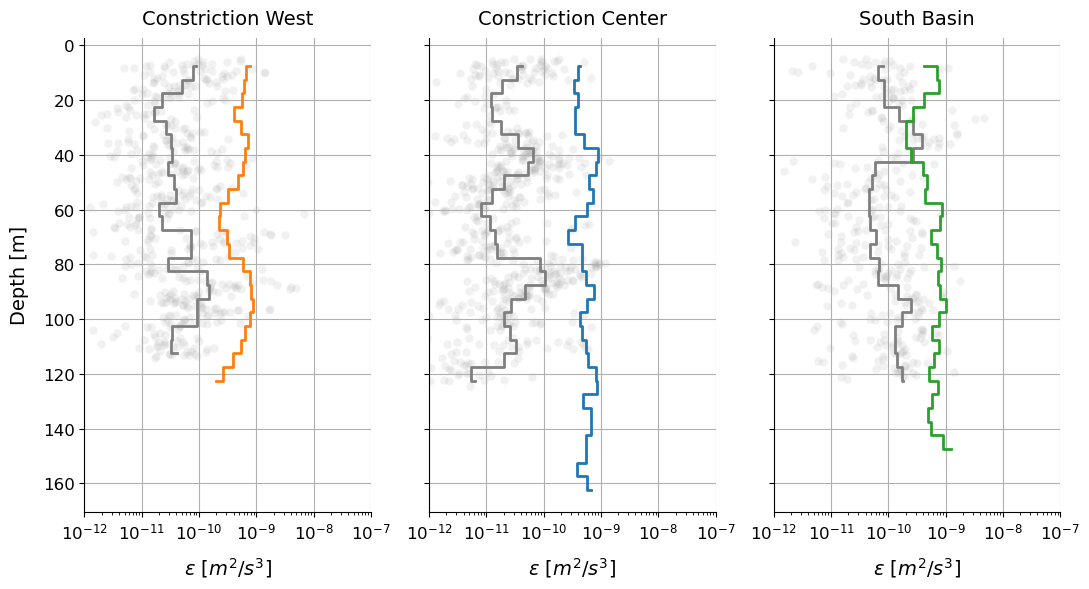

In [ ]:
# average CTD profiles at same location
data = data.replace(0, np.nan)
data_avg = (data.query("depth > 5")
    .assign(depth_bin = lambda x: (x['depth'] // 5) * 5 + 2.5)
    .groupby(['profile_loc', 'depth_bin'])[['eps', 'eps_temp', 'eps_do']]
    .median()
    .reset_index()
).rename(columns={'depth_bin': 'depth'})
#data_avg = data.query("depth > 5").groupby(['profile_loc', 'depth'])[['eps', 'eps_temp', 'eps_do']].mean().reset_index()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 6), sharey=True, sharex=True)
var_order = ['eps', 'eps_temp', 'eps_do']
palette = 'YlGnBu_d'

# VMPW
sns.scatterplot(x=eps_w, y=eps_w['BINNED_depth'], color='tab:gray', alpha=0.1, ax=ax[0])
sns.lineplot(x=eps_w_avg, y=bc_w, orient='y', color='tab:gray', linewidth=2, drawstyle="steps-mid", ax=ax[0])
sns.lineplot(data_avg.query("profile_loc == 'VMPW'"), x='eps', y='depth', orient='y', color='tab:orange', linewidth=2, drawstyle='steps-mid', ax=ax[0], legend=False)

# VMPC
sns.scatterplot(x=eps_c, y=eps_c['BINNED_depth'], color='tab:gray', alpha=0.1, ax=ax[1])
sns.lineplot(x=eps_c_avg, y=bc_c, orient='y', color='tab:gray', linewidth=2, drawstyle="steps-mid", ax=ax[1])
sns.lineplot(data_avg.query("profile_loc == 'VMPC'"), x='eps', y='depth', orient='y', color='tab:blue', linewidth=2, drawstyle='steps-mid', ax=ax[1], legend=False)

# VMPS
sns.scatterplot(x=eps_s, y=eps_s['BINNED_depth'], color='tab:gray', alpha=0.1, ax=ax[2])
sns.lineplot(x=eps_s_avg, y=bc_s, orient='y', color='tab:gray', linewidth=2, drawstyle="steps-mid", ax=ax[2])
sns.lineplot(data_avg.query("profile_loc == 'VMPS'"), x='eps', y='depth', orient='y', color='tab:green', linewidth=2, drawstyle='steps-mid', ax=ax[2])

ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[0].set_title('Constriction West', fontsize=14, pad=10)
ax[1].set_title('Constriction Center', fontsize=14, pad=10)
ax[2].set_title('South Basin', fontsize=14, pad=10)

ax[0].invert_yaxis()
ax[0].set_xlim(1e-12, 1e-7)
ax[0].set_xscale('log')

for i in range(len(ax)):
    ax[i].set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

plt.tight_layout()
plt.show()

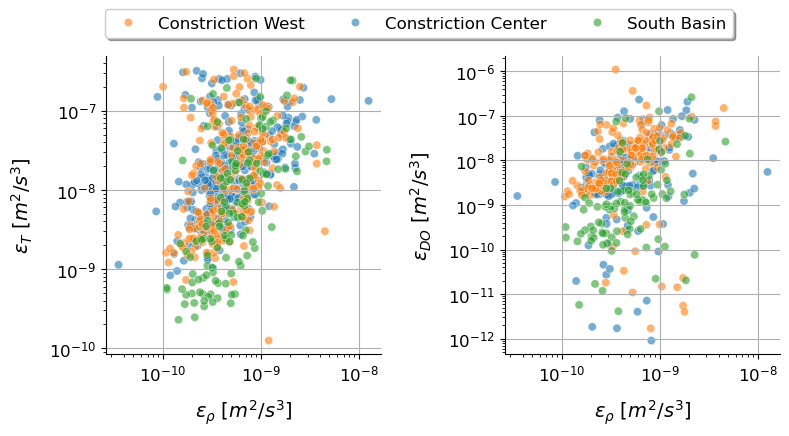

In [50]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
loc_order = ['VMPW', 'VMPC', 'VMPS']
palette = ['tab:orange', 'tab:blue', 'tab:green']

sns.scatterplot(data.query("depth > 5"), x='eps', y='eps_temp', hue='profile_loc', hue_order=loc_order, palette=palette, alpha=0.6, ax=ax[0], legend=False)
sns.scatterplot(data.query("depth > 5"), x='eps', y='eps_do', hue='profile_loc', hue_order=loc_order, palette=palette, alpha=0.6, ax=ax[1])

ax[0].set_ylabel(r'$\epsilon_{T}$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
ax[1].set_ylabel(r'$\epsilon_{DO}$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)

for i in range(len(ax)):
    ax[i].set_xlabel(r'$\epsilon_{\rho}$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].grid(True)

labels = ['Constriction West', 'Constriction Center', 'South Basin']
handles, _ = ax[1].get_legend_handles_labels()
ax[1].get_legend().remove()
fig.legend(handles, labels, fontsize=12, ncols=3, shadow=True, loc='upper center', bbox_to_anchor=(0.53, 1.1))

plt.tight_layout(w_pad=2)
plt.show()

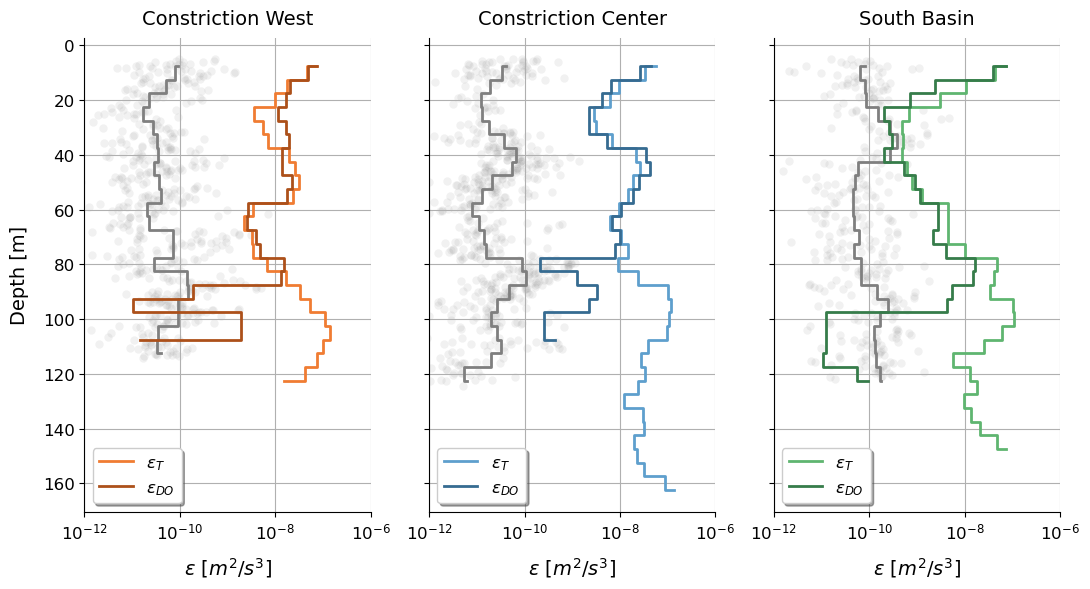

In [52]:
dfm = pd.melt(data_avg, id_vars=['profile_loc', 'depth'], value_vars=['eps_temp', 'eps_do'], var_name='calculation', value_name='epsilon')

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 6), sharey=True, sharex=True)
var_order = ['eps_temp', 'eps_do']
palette = 'YlGnBu_d'

# VMPW
sns.scatterplot(x=eps_w, y=eps_w['BINNED_depth'], color='tab:gray', alpha=0.1, ax=ax[0])
sns.lineplot(x=eps_w_avg, y=bc_w, orient='y', color='tab:gray', linewidth=2, drawstyle="steps-mid", ax=ax[0])
sns.lineplot(dfm.query("profile_loc == 'VMPW'"), x='epsilon', y='depth', orient='y', hue='calculation', hue_order=var_order, palette='Oranges_d', 
             linewidth=2, drawstyle='steps-mid', ax=ax[0])


# VMPC
sns.scatterplot(x=eps_c, y=eps_c['BINNED_depth'], color='tab:gray', alpha=0.1, ax=ax[1])
sns.lineplot(x=eps_c_avg, y=bc_c, orient='y', color='tab:gray', linewidth=2, drawstyle="steps-mid", ax=ax[1])
sns.lineplot(dfm.query("profile_loc == 'VMPC'"), x='epsilon', y='depth', orient='y', hue='calculation', hue_order=var_order, palette='Blues_d', 
             linewidth=2, drawstyle='steps-mid', ax=ax[1])

# VMPS
sns.scatterplot(x=eps_s, y=eps_s['BINNED_depth'], color='tab:gray', alpha=0.1, ax=ax[2])
sns.lineplot(x=eps_s_avg, y=bc_s, orient='y', color='tab:gray', linewidth=2, drawstyle="steps-mid", ax=ax[2])
sns.lineplot(dfm.query("profile_loc == 'VMPS'"), x='epsilon', y='depth', orient='y', hue='calculation', hue_order=var_order, palette='Greens_d', 
             linewidth=2, drawstyle='steps-mid', ax=ax[2])

ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[0].set_title('Constriction West', fontsize=14, pad=10)
ax[1].set_title('Constriction Center', fontsize=14, pad=10)
ax[2].set_title('South Basin', fontsize=14, pad=10)

ax[0].invert_yaxis()
ax[0].set_xlim(1e-12, 1e-6)
ax[0].set_xscale('log')

labels = [r'$\epsilon_{T}$', r'$\epsilon_{DO}$']
for i in range(len(ax)):
    ax[i].set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)
    handles, _ = ax[i].get_legend_handles_labels()
    ax[i].legend(handles, labels, fontsize=12, shadow=True)

plt.tight_layout()
plt.show()